In [1]:
!pip install diffusers accelerate -q



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading best model to cuda in FP16...
Processing image: BraTS20_Training_112_abnormal_slice_64.png


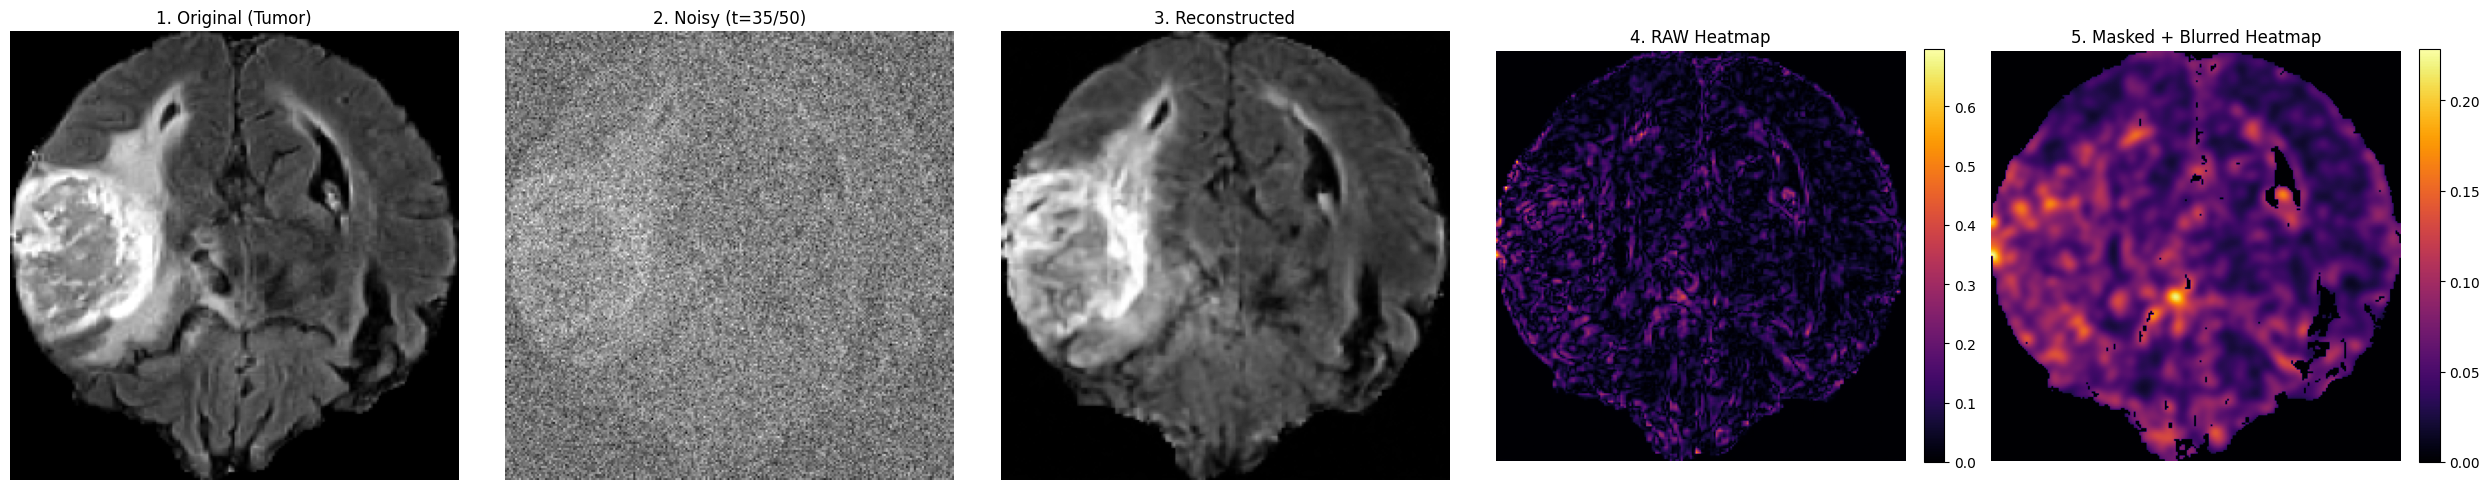

In [5]:
import torch
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2  # Added cv2 for the blur
from PIL import Image
from torchvision import transforms
from diffusers import UNet2DModel, DDIMScheduler

# --- 1. CONFIGURATION ---
CHECKPOINT_DIR = "best_model" 
ABNORMAL_DIR = "../Dataset/Processed_BraTS_AnomalyDetection/Test/Abnormal"
IMAGE_SIZE = 224

INFERENCE_STEPS = 50
START_STEP_INDEX = 35

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. LOAD MODEL & SCHEDULER ---
print(f"Loading best model to {device} in FP16...")
model = UNet2DModel.from_pretrained(CHECKPOINT_DIR, torch_dtype=torch.float16).to(device)
model.eval()

scheduler = DDIMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(INFERENCE_STEPS)
t_start = scheduler.timesteps[START_STEP_INDEX]

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# --- 3. PROCESS WITH BLUR & MASK ---
abnormal_files = [f for f in os.listdir(ABNORMAL_DIR) if f.endswith('.png')]
img_path = os.path.join(ABNORMAL_DIR, random.choice(abnormal_files))

print(f"Processing image: {os.path.basename(img_path)}")

@torch.no_grad()
def visualize_pipeline(image_path):
    original_pil = Image.open(image_path)
    input_tensor = transform(original_pil).unsqueeze(0).to(device, dtype=torch.float16)

    # Add noise
    noise = torch.randn_like(input_tensor, dtype=torch.float16)
    noisy_image = scheduler.add_noise(input_tensor, noise, torch.tensor([t_start], device=device))

    # Denoise
    reconstructed = noisy_image.clone()
    for t in scheduler.timesteps[START_STEP_INDEX:]:
        noise_pred = model(reconstructed, t).sample
        reconstructed = scheduler.step(noise_pred, t, reconstructed).prev_sample

    # Convert to Numpy
    orig_np = (input_tensor.squeeze() / 2 + 0.5).cpu().to(torch.float32).numpy()
    noisy_np = (noisy_image.squeeze() / 2 + 0.5).cpu().to(torch.float32).numpy()
    recon_np = (reconstructed.squeeze() / 2 + 0.5).cpu().to(torch.float32).numpy()
    
    # 1. RAW HEATMAP (The messy one)
    raw_anomaly_map = np.abs(orig_np - recon_np)
    
    # 2. THE FIX: BLUR + MASK (The clean one)
    blurred_map = cv2.GaussianBlur(raw_anomaly_map, (15, 15), 0)
    brain_mask = (orig_np > 0.05).astype(np.float32) 
    final_anomaly_map = blurred_map * brain_mask
    
    # Free VRAM
    del input_tensor, noise, noisy_image, reconstructed, noise_pred
    torch.cuda.empty_cache()

    return orig_np, noisy_np, recon_np, raw_anomaly_map, final_anomaly_map

orig, noisy, recon, raw_map, final_map = visualize_pipeline(img_path)

# --- 4. PLOT 5 PANELS ---
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(orig, cmap='gray')
axes[0].set_title("1. Original (Tumor)")
axes[0].axis('off')

axes[1].imshow(noisy, cmap='gray')
axes[1].set_title(f"2. Noisy (t={START_STEP_INDEX}/{INFERENCE_STEPS})")
axes[1].axis('off')

axes[2].imshow(recon, cmap='gray')
axes[2].set_title("3. Reconstructed")
axes[2].axis('off')

# The old way
im1 = axes[3].imshow(raw_map, cmap='inferno')
axes[3].set_title("4. RAW Heatmap")
axes[3].axis('off')
fig.colorbar(im1, ax=axes[3], fraction=0.046, pad=0.04)

# The new, fixed way
im2 = axes[4].imshow(final_map, cmap='inferno')
axes[4].set_title("5. Masked + Blurred Heatmap")
axes[4].axis('off')
fig.colorbar(im2, ax=axes[4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Loading best model to cuda in FP16...
Processing image: BraTS20_Training_215_abnormal_slice_74.png


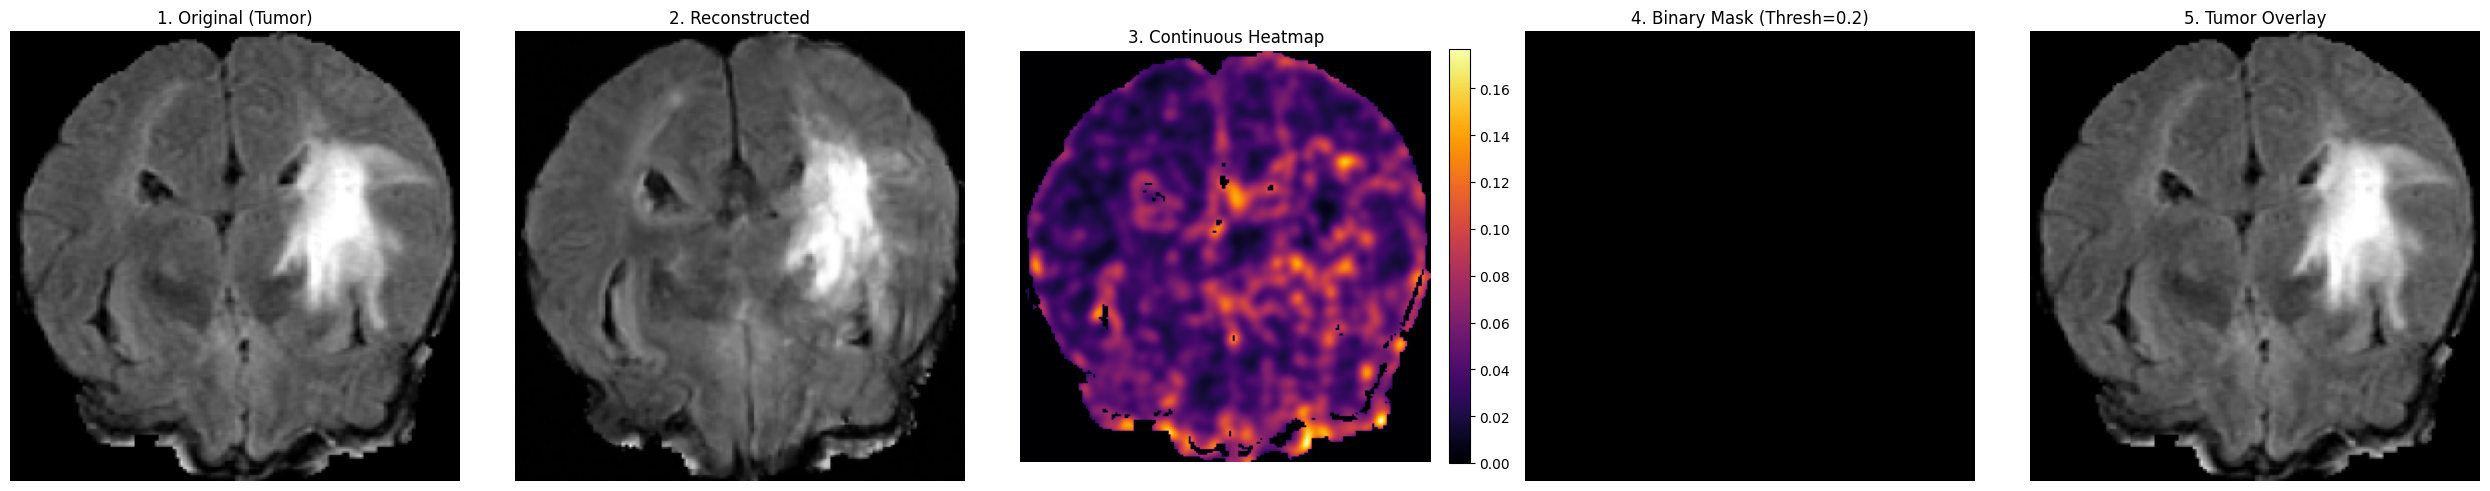

In [1]:
import torch
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2  
from PIL import Image
from torchvision import transforms
from diffusers import UNet2DModel, DDIMScheduler

# --- 1. CONFIGURATION ---
CHECKPOINT_DIR = "best_model" 
ABNORMAL_DIR = "../Dataset/Processed_BraTS_AnomalyDetection/Test/Abnormal"
IMAGE_SIZE = 224

INFERENCE_STEPS = 50
START_STEP_INDEX = 35

# NEW: The threshold to determine what counts as a tumor. 
# You may need to tune this up or down (e.g., 0.15 to 0.3) based on your results.
TUMOR_THRESHOLD = 0.20 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. LOAD MODEL & SCHEDULER ---
print(f"Loading best model to {device} in FP16...")
model = UNet2DModel.from_pretrained(CHECKPOINT_DIR, torch_dtype=torch.float16).to(device)
model.eval()

scheduler = DDIMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(INFERENCE_STEPS)
t_start = scheduler.timesteps[START_STEP_INDEX]

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# --- 3. PROCESS WITH BLUR, MASK, AND THRESHOLD ---
abnormal_files = [f for f in os.listdir(ABNORMAL_DIR) if f.endswith('.png')]
img_path = os.path.join(ABNORMAL_DIR, random.choice(abnormal_files))

print(f"Processing image: {os.path.basename(img_path)}")

@torch.no_grad()
def visualize_pipeline(image_path):
    original_pil = Image.open(image_path)
    input_tensor = transform(original_pil).unsqueeze(0).to(device, dtype=torch.float16)

    # Add noise
    noise = torch.randn_like(input_tensor, dtype=torch.float16)
    noisy_image = scheduler.add_noise(input_tensor, noise, torch.tensor([t_start], device=device))

    # Denoise
    reconstructed = noisy_image.clone()
    for t in scheduler.timesteps[START_STEP_INDEX:]:
        noise_pred = model(reconstructed, t).sample
        reconstructed = scheduler.step(noise_pred, t, reconstructed).prev_sample

    # Convert to Numpy
    orig_np = (input_tensor.squeeze() / 2 + 0.5).cpu().to(torch.float32).numpy()
    noisy_np = (noisy_image.squeeze() / 2 + 0.5).cpu().to(torch.float32).numpy()
    recon_np = (reconstructed.squeeze() / 2 + 0.5).cpu().to(torch.float32).numpy()
    
    # 1. RAW HEATMAP
    raw_anomaly_map = np.abs(orig_np - recon_np)
    
    # 2. BLUR + BRAIN MASK
    blurred_map = cv2.GaussianBlur(raw_anomaly_map, (15, 15), 0)
    brain_mask = (orig_np > 0.05).astype(np.float32) 
    final_anomaly_map = blurred_map * brain_mask
    
    # --- NEW: 3. BINARY TUMOR MASK ---
    # Convert the continuous heatmap into a strict 1 (Tumor) or 0 (Healthy)
    binary_tumor_mask = (final_anomaly_map > TUMOR_THRESHOLD).astype(np.float32)
    
    # --- NEW: 4. RED OVERLAY ---
    # Stack the grayscale image into 3 channels (RGB) so we can draw in color
    overlay = np.stack((orig_np, orig_np, orig_np), axis=-1)
    # Wherever the mask is 1, turn that pixel pure Red [R=1, G=0, B=0]
    overlay[binary_tumor_mask == 1] = [1.0, 0.0, 0.0] 
    
    # Free VRAM
    del input_tensor, noise, noisy_image, reconstructed, noise_pred
    torch.cuda.empty_cache()

    return orig_np, recon_np, final_anomaly_map, binary_tumor_mask, overlay

orig, recon, final_map, binary_mask, overlay = visualize_pipeline(img_path)

# --- 4. PLOT 5 PANELS ---
# Swapped out the noisy image to make room for the new masks
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(orig, cmap='gray')
axes[0].set_title("1. Original (Tumor)")
axes[0].axis('off')

axes[1].imshow(recon, cmap='gray')
axes[1].set_title("2. Reconstructed")
axes[1].axis('off')

im1 = axes[2].imshow(final_map, cmap='inferno')
axes[2].set_title("3. Continuous Heatmap")
axes[2].axis('off')
fig.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)

axes[3].imshow(binary_mask, cmap='gray')
axes[3].set_title(f"4. Binary Mask (Thresh={TUMOR_THRESHOLD})")
axes[3].axis('off')

axes[4].imshow(overlay)
axes[4].set_title("5. Tumor Overlay")
axes[4].axis('off')

plt.tight_layout()
plt.show()

In [3]:
import torch
import torch.nn.functional as F
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from diffusers import UNet2DModel, DDIMScheduler
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

# --- 1. CONFIGURATION ---
CHECKPOINT_DIR = "best_model" 
TEST_HEALTHY_DIR = "../Dataset/Processed_BraTS_AnomalyDetection/Test/Healthy"
TEST_ABNORMAL_DIR = "../Dataset/Processed_BraTS_AnomalyDetection/Test/Abnormal"
IMAGE_SIZE = 224
BATCH_SIZE = 11
  # Adjust based on your VRAM (T4 handles 8-16 easily)

# Anomaly Detection Knobs
INFERENCE_STEPS = 50
START_STEP_INDEX = 18 
DOWNSCALE_FACTOR = 8
TOP_K_PERCENT = 0.01 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. DATASET CLASS ---
class BraTSAnomalyDataset(Dataset):
    def __init__(self, healthy_dir, abnormal_dir, transform=None):
        self.files = []
        for f in os.listdir(healthy_dir):
            if f.endswith('.png'):
                self.files.append((os.path.join(healthy_dir, f), 0))
        for f in os.listdir(abnormal_dir):
            if f.endswith('.png'):
                self.files.append((os.path.join(abnormal_dir, f), 1))
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path, label = self.files[idx]
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)
        return image, label, os.path.basename(img_path)

# --- 3. HELPER FUNCTIONS ---
def get_blobby_noise_batch(tensor, downscale_factor=8):
    b, c, h, w = tensor.shape
    small_noise = torch.randn((b, c, h // downscale_factor, w // downscale_factor), 
                              device=tensor.device, dtype=tensor.dtype)
    blobby_noise = F.interpolate(small_noise, size=(h, w), mode='bilinear', align_corners=False)
    # Normalize per-batch-item to maintain correct noise schedule
    std = blobby_noise.view(b, -1).std(dim=1).view(b, 1, 1, 1)
    return blobby_noise / std

# --- 4. PREPARE MODEL & LOADER ---
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = BraTSAnomalyDataset(TEST_HEALTHY_DIR, TEST_ABNORMAL_DIR, transform=transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

model = UNet2DModel.from_pretrained(CHECKPOINT_DIR, torch_dtype=torch.float16).to(device)
model.eval()

scheduler = DDIMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(INFERENCE_STEPS)
t_start = scheduler.timesteps[START_STEP_INDEX]

# --- 5. BATCH INFERENCE LOOP ---
all_scores, all_labels = [], []
visuals = []

print(f"Starting batch inference on {len(dataset)} images...")
with torch.no_grad():
    for images, labels, names in tqdm(loader):
        images = images.to(device, dtype=torch.float16)
        
        # 1. Add Noise
        noise = get_blobby_noise_batch(images, DOWNSCALE_FACTOR)
        noisy_images = scheduler.add_noise(images, noise, torch.tensor([t_start], device=device))

        # 2. Iterative Denoising
        reconstructed = noisy_images.clone()
        for t in scheduler.timesteps[START_STEP_INDEX:]:
            noise_pred = model(reconstructed, t).sample
            reconstructed = scheduler.step(noise_pred, t, reconstructed).prev_sample

        # 3. Process Batch Metrics
        orig_np = (images / 2 + 0.5).cpu().to(torch.float32).numpy()
        recon_np = (reconstructed / 2 + 0.5).cpu().to(torch.float32).numpy()
        
        for i in range(images.shape[0]):
            raw_map = np.abs(orig_np[i, 0] - recon_np[i, 0])
            
            # Brain mask to remove background artifacts
            mask = (orig_np[i, 0] > 0.1).astype(np.float32)
            final_map = cv2.GaussianBlur(raw_map, (11, 11), 0) * mask
            
            # Top-K pixel score
            flat_map = final_map.flatten()
            top_k = int(len(flat_map) * TOP_K_PERCENT)
            score = np.mean(np.sort(flat_map)[-top_k:])
            
            all_scores.append(score)
            all_labels.append(labels[i].item())
            
            # Save visual samples (first 3 from both classes)
            if len(visuals) < 12:
                visuals.append({
                    'orig': orig_np[i, 0], 'recon': recon_np[i, 0], 
                    'map': final_map, 'score': score, 'label': labels[i].item()
                })

# --- 6. CALCULATE METRICS & PLOT GRAPHS ---
auroc = roc_auc_score(all_labels, all_scores)
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)

# Find optimal threshold using Youden's J statistic
idx = np.argmax(tpr - fpr)
opt_threshold = thresholds[idx]
accuracy = accuracy_score(all_labels, [1 if s >= opt_threshold else 0 for s in all_scores])

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auroc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()
plt.show()

print(f"Evaluation Complete | AUROC: {auroc:.4f} | Accuracy: {accuracy:.4f}")

# --- 7. PLOT HEATMAP GRID ---
fig, axes = plt.subplots(6, 3, figsize=(12, 24))
for i, res in enumerate(visuals[:6]): # Show top samples
    is_correct = (res['score'] >= opt_threshold) == res['label']
    title_color = 'green' if is_correct else 'red'
    label_str = "Abnormal" if res['label'] == 1 else "Healthy"
    
    axes[i, 0].imshow(res['orig'], cmap='gray')
    axes[i, 0].set_title(f"Original ({label_str})")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(res['recon'], cmap='gray')
    axes[i, 1].set_title(f"Reconstruction")
    axes[i, 1].axis('off')

    im = axes[i, 2].imshow(res['map'], cmap='hot')
    axes[i, 2].set_title(f"Score: {res['score']:.4f}", color=title_color)
    axes[i, 2].axis('off')
    plt.colorbar(im, ax=axes[i, 2])

plt.tight_layout()
plt.show()

Starting batch inference on 3910 images...


  0%|          | 0/356 [00:00<?, ?it/s]

KeyboardInterrupt: 